#  예제 4: 수요 예측 AI (Prophet 시계열 모델)

---

## 이 예제에서 배울 것
- **시계열 데이터**: 시간 순서가 있는 데이터(주문량, 생산량 등)의 특성
- **Prophet**: Meta(구 Facebook)가 만든 시계열 예측 AI (사용 매우 쉬움!)
- **계절성**: AI가 자동으로 주기적 패턴(계절·월별 변동)을 발견하는 원리

## 핵심 메시지
> **"과거 패턴이 미래에도 반복된다면, AI가 예측할 수 있다."**  
> 2년치 주문 데이터로 향후 6개월 수요를 예측합니다.

## 제조 현장 연관
- 수요예측으로 **생산 계획 수립**, **원자재 발주량** 결정
- 재고 과부족 방지 → **비용 절감** + **납기 준수율 향상**
- **KPF** 자동차부품: 고객사 주문량 예측 → 생산 평준화

---
## Prophet이란?
- Meta(페이스북)이 2017년 오픈소스로 공개한 시계열 예측 도구 (**단변수 예측 모델임!**)
- 특징: **사용이 매우 쉽고**, 계절성·이벤트를 자동으로 처리
- 단 10줄 코드로 전문적인 수요예측 AI 완성!

In [1]:
# ─────────────────────────────────────────────────────────
# Prophet 설치
# 처음 실행 시 1~3분 소요됩니다. 잠시 기다려 주세요!
# ─────────────────────────────────────────────────────────
print("Prophet 설치 중... (처음 실행 시 1~3분 소요)")
!pip install -q prophet koreanize-matplotlib
%config InlineBackend.figure_format = 'retina'
print("✅ 설치 완료!")

Prophet 설치 중... (처음 실행 시 1~3분 소요)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 36.9 MB/s eta 0:00:00
✅ 설치 완료!


In [2]:
# ─────────────────────────────────────────────────────────
# 필요한 도구 불러오기
# ─────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import koreanize_matplotlib

# Prophet: Meta가 만든 시계열 예측 라이브러리
from prophet import Prophet

import warnings
warnings.filterwarnings('ignore')

print(" 모든 도구 준비 완료!")

 모든 도구 준비 완료!


## STEP 1: 과거 주문량 데이터 준비

**Prophet이 요구하는 데이터 형식:**
- `ds` (date string): 날짜 컬럼 — 반드시 이 이름 사용!
- `y` (y-value): 예측하려는 값 — 반드시 이 이름 사용!

In [3]:
# ─────────────────────────────────────────────────────────
# 자동차 부품 2년치 주문량 데이터 생성 (주별 데이터)
# 실제 현장에서는 ERP/SAP에서 주문 이력을 추출
# ─────────────────────────────────────────────────────────
np.random.seed(42)

# 2022년~2023년, 주별(W=Week) 데이터
날짜 = pd.date_range('2022-01-01', '2023-12-31', freq='W')  # freq='W': 주별
n = len(날짜)
print(f"데이터 기간: {날짜[0].date()} ~ {날짜[-1].date()} ({n}주)")

# ─────────────────────────────────────────────────────────
# 현실적인 수요 패턴 생성:
#   1. 완만한 성장 트렌드 (연간 10% 성장)
#   2. 계절성: 여름(7~8월) 감소, 연말(11~12월) 증가
#   3. 랜덤 노이즈 (예측 불가능한 변동)
# ─────────────────────────────────────────────────────────

# np.linspace(시작, 끝, 개수): 균등 간격으로 숫자 생성
# → 500에서 시작해서 700으로 서서히 증가하는 트렌드
트렌드 = np.linspace(500, 700, n)

# 연간 계절성 (사인 함수로 주기적 패턴 생성)
# np.sin: 사인 함수 / np.pi: 파이(π = 3.14159...)
# 2*pi/52 = 1년(52주)을 한 주기로 반복
계절성 = 80 * np.sin(2 * np.pi * np.arange(n) / 52)

# 랜덤 노이즈 (예측 불가능한 시장 변동)
노이즈 = np.random.normal(0, 30, n)

# 최종 주문량 = 트렌드 + 계절성 + 노이즈
주문량 = (트렌드 + 계절성 + 노이즈).clip(min=100)  # clip: 최소값 100으로 제한

# ─────────────────────────────────────────────────────────
# Prophet 전용 형식으로 변환
# ⚠️ Prophet은 반드시 'ds'와 'y' 컬럼 이름을 사용해야 합니다!
# ─────────────────────────────────────────────────────────
df = pd.DataFrame({
    'ds': 날짜,       # ds = date string (날짜)
    'y': 주문량        # y = 예측 대상 값
})

print(f"\n 주문 데이터 준비 완료: {len(df)}주")
print(f"   평균 주문량: {df['y'].mean():.0f}개/주")
print(f"   최소: {df['y'].min():.0f}개 | 최대: {df['y'].max():.0f}개")

print("\n📋 Prophet 입력 형식 확인 (처음 3행):")
df.head(3)

데이터 기간: 2022-01-02 ~ 2023-12-31 (105주)

 주문 데이터 준비 완료: 105주
   평균 주문량: 596개/주
   최소: 435개 | 최대: 746개

📋 Prophet 입력 형식 확인 (처음 3행):


,ds,y
0,2022-01-02,514.901425
1,2022-01-09,507.418082
2,2022-01-16,542.422063


## STEP 2: Prophet 모델 학습

Prophet의 강점: **단 3줄**로 학습 완료!

In [4]:
# ─────────────────────────────────────────────────────────
# Prophet 모델 생성 및 학습
# ─────────────────────────────────────────────────────────
print("Prophet 모델 학습 중...")

model = Prophet(
    yearly_seasonality=True,   # 연간 계절성 자동 학습 (ON)
    weekly_seasonality=False,  # 주간 계절성 (주별 데이터라 불필요)
    daily_seasonality=False,   # 일별 계절성 (주별 데이터라 불필요)
    changepoint_prior_scale=0.05  # 트렌드 변화 민감도
    # 값이 클수록: 트렌드 변화에 민감 (과적합 위험)
    # 값이 작을수록: 트렌드 변화에 둔감 (과소적합 위험)
    # 0.05가 일반적인 기본값
)

# fit(): 데이터로 모델 학습
# Prophet은 내부적으로 베이즈 통계를 사용하여 패턴을 학습합니다
model.fit(df)

print(" 학습 완료!")

Prophet 모델 학습 중...
 학습 완료!


## STEP 3: 향후 26주(6개월) 예측

In [5]:
# ─────────────────────────────────────────────────────────
# 미래 날짜 생성 및 예측
# ─────────────────────────────────────────────────────────

# make_future_dataframe(): 미래 날짜를 자동으로 생성
# periods=26: 26주 앞까지 예측
# freq='W': 주별 간격
미래_날짜 = model.make_future_dataframe(periods=26, freq='W')

print(f"예측 대상: {미래_날짜.tail(1)['ds'].values[0]} 까지")

# predict(): 생성된 날짜에 대한 예측값 계산
예측 = model.predict(미래_날짜)

# 예측 결과 컬럼 설명:
# yhat:       예측값 (가장 가능성 높은 값)
# yhat_lower: 예측 하한선 (80% 신뢰구간)
# yhat_upper: 예측 상한선 (80% 신뢰구간)

print("\n 예측 완료!")
print("예측 결과 컬럼:")
print(예측[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(3))

예측 대상: 2024-06-30T00:00:00.000000000 까지

 예측 완료!
예측 결과 컬럼:
            ds        yhat  yhat_lower  yhat_upper
128 2024-06-16  766.985451  735.238133  799.085278
129 2024-06-23  757.475387  726.035300  790.032026
130 2024-06-30  743.433025  711.475246  773.221003


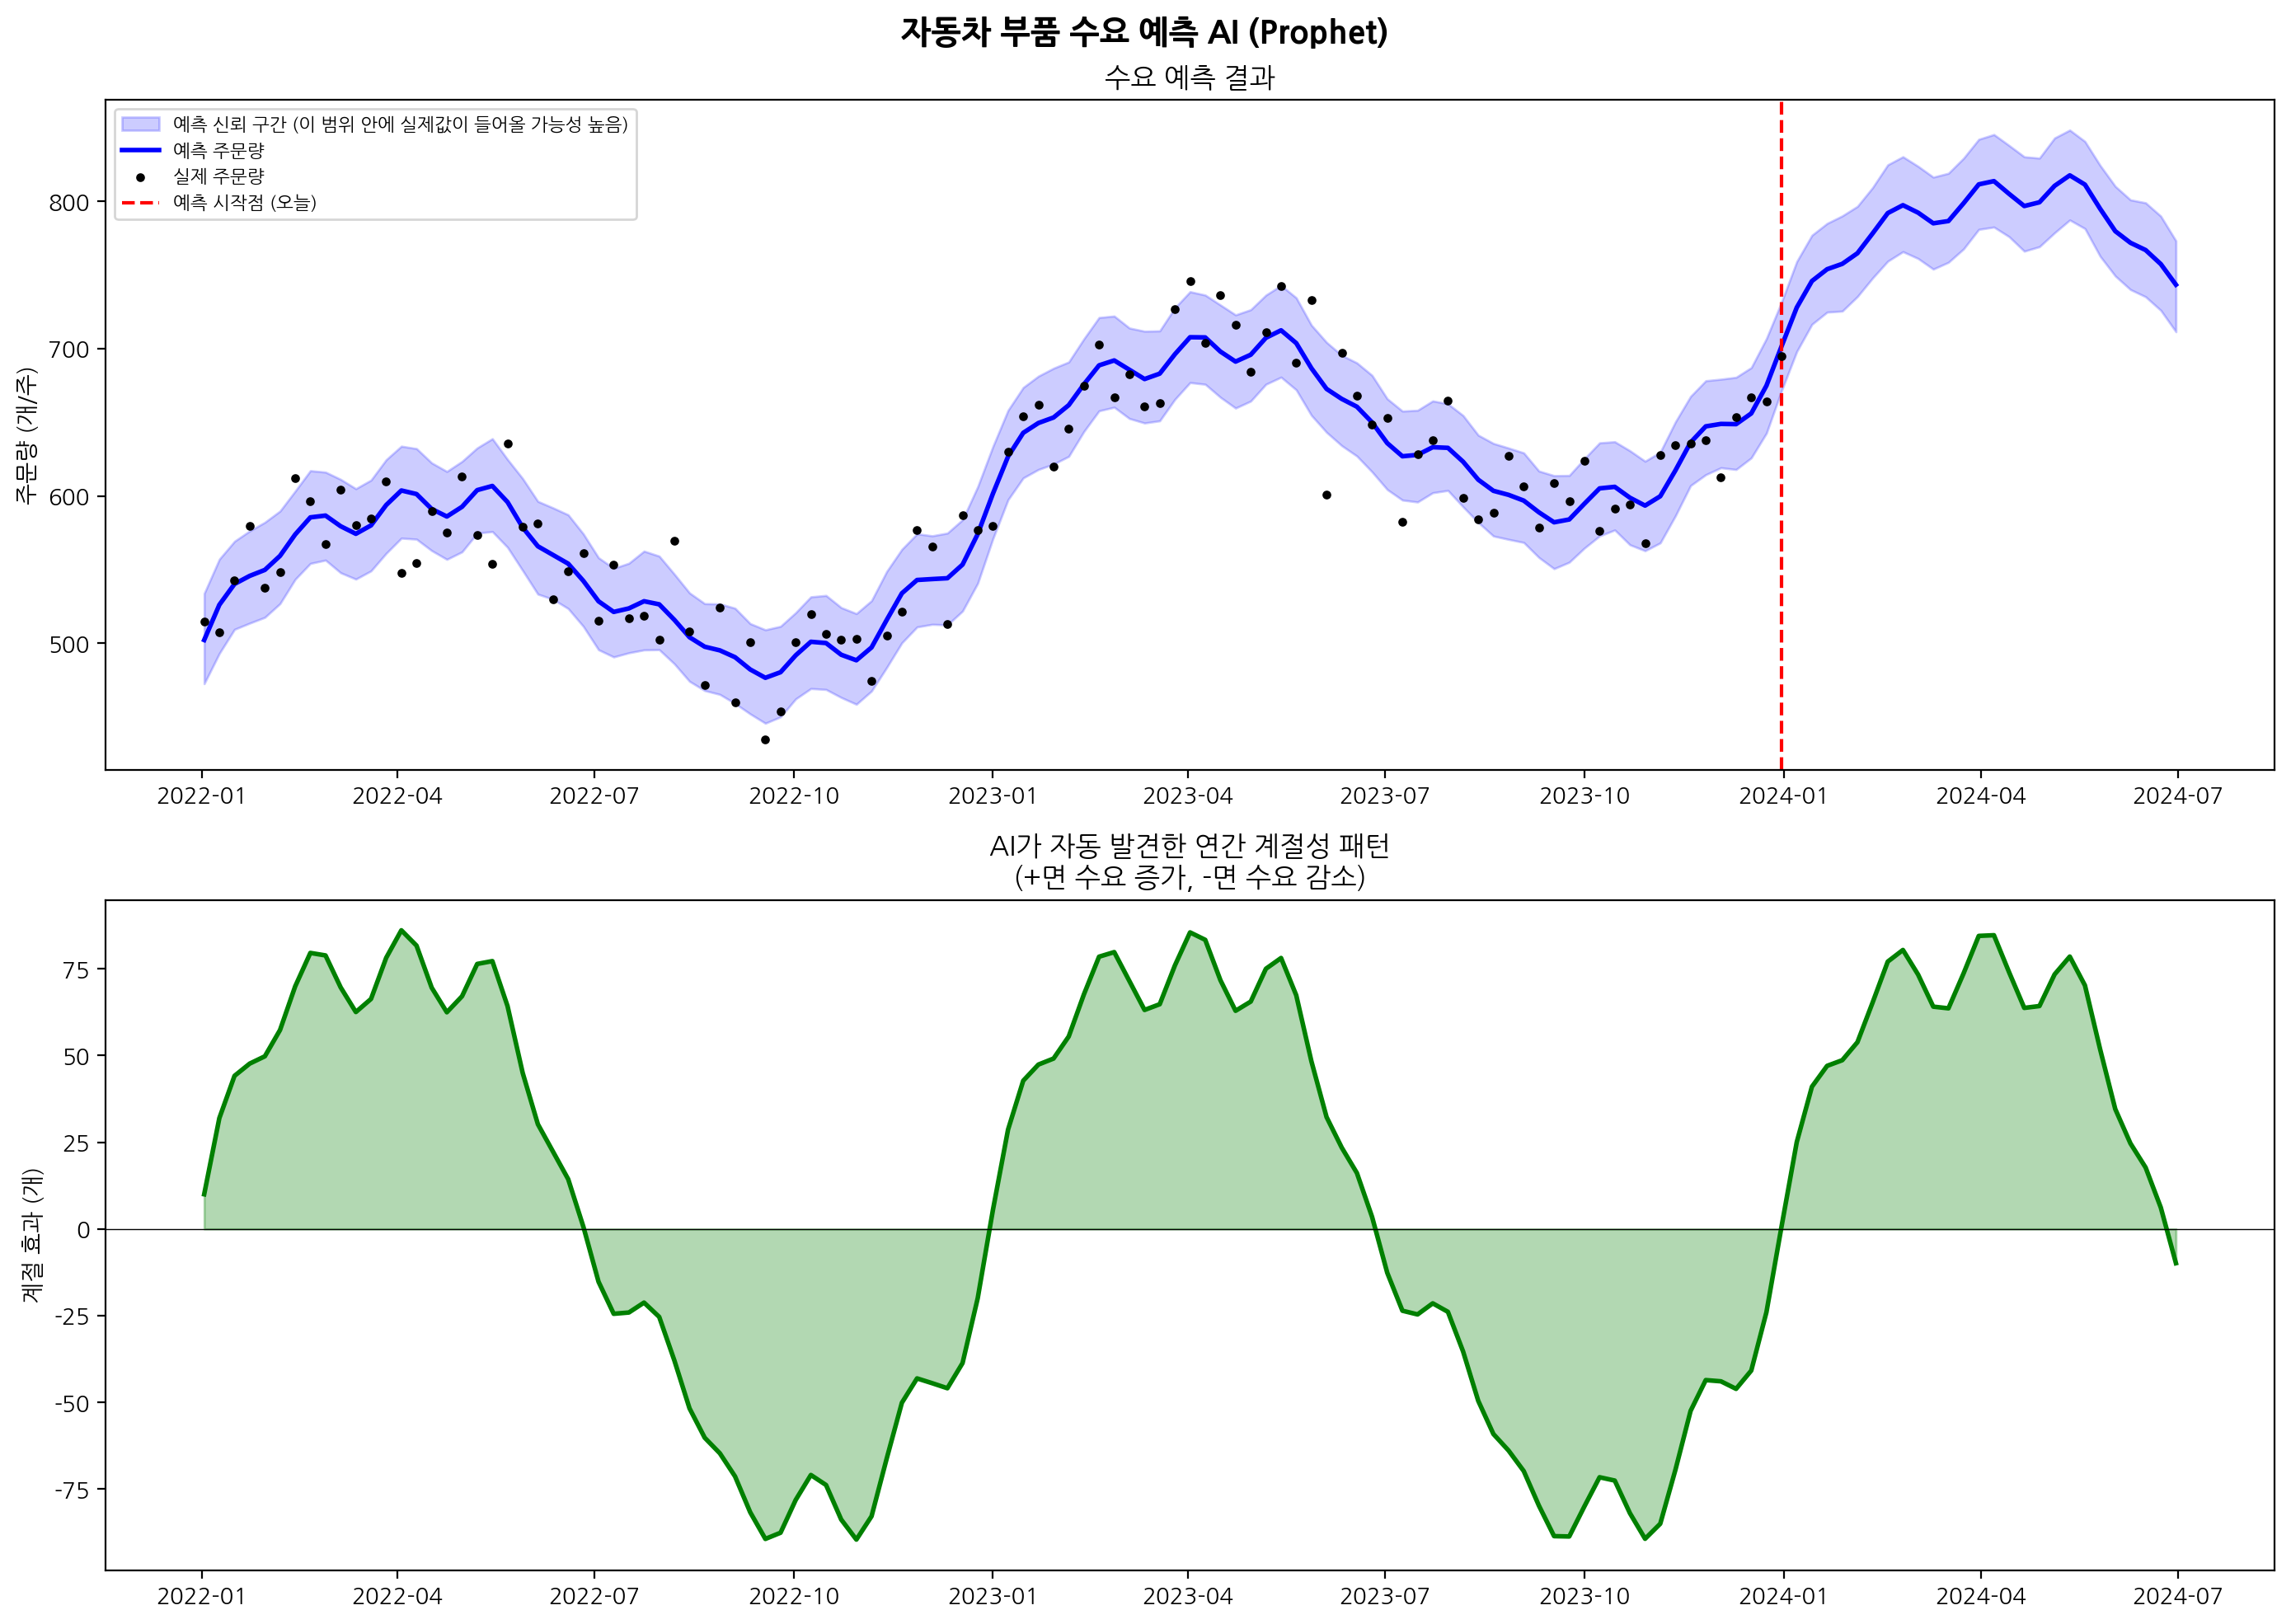

In [6]:
# ─────────────────────────────────────────────────────────
# 시각화: 예측 결과 + 계절성 패턴
# ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 10))
fig.suptitle('자동차 부품 수요 예측 AI (Prophet)', fontsize=14, fontweight='bold')

# ─── 그래프 1: 전체 예측 결과 ──────────────────────────────
# 신뢰 구간 (파란 영역): 예측값의 불확실성 범위
# fill_between: 두 선 사이를 색으로 채우기
axes[0].fill_between(
    예측['ds'],           # x축: 날짜
    예측['yhat_lower'],   # 아래 경계선
    예측['yhat_upper'],   # 위 경계선
    alpha=0.2,            # 투명도
    color='blue',
    label='예측 신뢰 구간 (이 범위 안에 실제값이 들어올 가능성 높음)'
)

# 예측선
axes[0].plot(예측['ds'], 예측['yhat'],
             'b-', linewidth=2, label='예측 주문량')

# 실제 데이터 점
axes[0].scatter(df['ds'], df['y'],
                color='black', s=8, label='실제 주문량', zorder=5)

# 예측 시작 기준선
axes[0].axvline(x=df['ds'].max(), color='red',
                linestyle='--', label='예측 시작점 (오늘)')

axes[0].set_title('수요 예측 결과', fontsize=12)
axes[0].set_ylabel('주문량 (개/주)')
axes[0].legend(fontsize=8)

# ─── 그래프 2: AI가 발견한 연간 계절성 패턴 ───────────────
# 연간 계절성 컬럼 추출
계절성_패턴 = 예측[['ds', 'yearly']]

axes[1].plot(계절성_패턴['ds'], 계절성_패턴['yearly'],
             'g-', linewidth=2)
axes[1].fill_between(계절성_패턴['ds'], 계절성_패턴['yearly'],
                     alpha=0.3, color='green')
axes[1].axhline(y=0, color='black', linestyle='-', linewidth=0.5)  # 기준선

axes[1].set_title('AI가 자동 발견한 연간 계절성 패턴\n(+면 수요 증가, -면 수요 감소)', fontsize=12)
axes[1].set_ylabel('계절 효과 (개)')

plt.tight_layout()
plt.show()

## STEP 4: 생산 계획에 활용 — 향후 4주 예측값 출력

In [7]:
# ─────────────────────────────────────────────────────────
# 향후 4주 예측값을 생산 계획 형식으로 정리
# ─────────────────────────────────────────────────────────

# 예측값 중 미래 데이터만 필터링
미래_예측 = 예측[예측['ds'] > df['ds'].max()]  # 오늘 이후 날짜만
미래_예측 = 미래_예측[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].head(4)  # 4주만

print("=" * 65)
print("📅 향후 4주 수요 예측 (생산 계획 참고용)")
print("=" * 65)
print(f"{'주차':^6} {'날짜':^12} {'예측 주문량':^12} {'최소':^10} {'최대':^10}")
print("-" * 65)

for i, (_, row) in enumerate(미래_예측.iterrows()):
    # iterrows(): 각 행을 (인덱스, 데이터) 형태로 꺼냄
    # _: 인덱스는 쓰지 않으므로 _로 표기 (관례)
    날짜_str = str(row['ds'].date())  # 날짜를 문자열로 변환
    print(f"  {i+1}주차  {날짜_str:^12} "
          f"{row['yhat']:^12.0f} "
          f"{row['yhat_lower']:^10.0f} "
          f"{row['yhat_upper']:^10.0f}")

print("=" * 65)

# MAPE (평균 절대 백분율 오차) 계산 — 예측 정확도 지표
# 학습 데이터 기간의 예측 오차로 계산
학습기간_예측 = 예측[예측['ds'] <= df['ds'].max()].copy()
학습기간_예측 = 학습기간_예측.merge(df, on='ds', how='inner')

if len(학습기간_예측) > 0:
    # MAPE = |실제 - 예측| / 실제 × 100
    mape = (abs(학습기간_예측['y'] - 학습기간_예측['yhat']) / 학습기간_예측['y']).mean() * 100
    print(f"\n 모델 정확도 지표 (MAPE): {mape:.1f}%")
    print(f"   → MAPE {mape:.1f}% = 예측값이 실제와 평균 {mape:.1f}% 차이")
    print(f"   → 제조업 기준: 10% 이하 = 우수 / 15% 이하 = 양호")

print("\n 생산 계획 수립 방법:")
print("  - '예측 주문량'을 기준으로 생산 계획 수립")
print("  - '최소~최대' 범위를 고려하여 원자재 발주량 결정")
print("  - 안전재고 = 최대 예측량 기준으로 설정 (납기 안정성)")

📅 향후 4주 수요 예측 (생산 계획 참고용)
  주차        날짜         예측 주문량        최소         최대    
-----------------------------------------------------------------
  1주차   2024-01-07      728         698        759    
  2주차   2024-01-14      746         717        777    
  3주차   2024-01-21      754         725        785    
  4주차   2024-01-28      758         725        790    

 모델 정확도 지표 (MAPE): 3.4%
   → MAPE 3.4% = 예측값이 실제와 평균 3.4% 차이
   → 제조업 기준: 10% 이하 = 우수 / 15% 이하 = 양호

 생산 계획 수립 방법:
  - '예측 주문량'을 기준으로 생산 계획 수립
  - '최소~최대' 범위를 고려하여 원자재 발주량 결정
  - 안전재고 = 최대 예측량 기준으로 설정 (납기 안정성)


## 🎓 정리 및 핵심 포인트

### 배운 것
1. **시계열 데이터**: 시간 순서가 중요한 데이터 (과거 → 현재 → 미래)
2. **Prophet**: 날짜 컬럼을 `ds`, 값 컬럼을 `y`로 맞추면 바로 사용 가능
3. **신뢰 구간**: 예측에는 불확실성이 있음 → 최소/최대 범위로 계획 수립
4. **MAPE**: 수요예측 AI의 정확도 지표 (낮을수록 좋음, 10% 이하 우수)

### Prophet 사용 시 주의사항
- **최소 데이터**: 계절성 학습을 위해 **2년 이상** 주문 이력 필요
- **이상치 처리**: 코로나, 파업 등 특수 상황 기간은 제외하거나 별도 처리
- **외부 변수**: 고객사 생산 계획 등 외부 정보를 추가 변수로 활용 가능

### 실제 ROI 사례
- 수요예측 AI 도입 시 평균 **재고 비용 15~25% 절감**
- **납기 준수율 5~10%p 향상** (과부족 생산 감소)

### 다음 단계
**예제 5**에서는 Claude API를 활용하여 분석 결과를 자동으로 보고서로 만드는 방법을 배웁니다! 📝

---
*송현그룹 mAX Academy 3기 | 예제 4/6*